# **SUGAR TRAP ANALYSIS**

### **INSTALL LIBRARIES NEEDED FOR THE PROJECT**

In [ ]:
# Install any missing libraries
!pip install pandas matplotlib seaborn plotly -q

### **IMPORTING LIBRARIES**

In [ ]:
# Import everything we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")


All libraries loaded successfully!


## **DATA INGESTION & THE CLEAN UP - STORY 1 (CELLS 3-12)**

In [ ]:
!wget -q --show-progress "https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz" -O food_facts.csv.gz

print("downloaded successfully")

food_facts.csv.gz   100%[===================>]   1.16G  34.9MB/s    in 33s     
downloaded successfully


### **LOAD THE DATASET**

In [ ]:
df_raw = pd.read_csv(
    'food_facts.csv.gz',
    nrows=500000,
    sep='\t',               # This file uses TAB not comma as separator
    low_memory=False,       # fix data type issue, read the entire file before derterming data type
    on_bad_lines='skip'     # Skip any corrupted rows
)

print(f"Dataset loaded")
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")


Dataset loaded
Shape: 500,000 rows × 210 columns


### **PREVIEW THE RAW DATA**

In [ ]:
df_raw.head()

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,last_modified_by,last_updated_t,last_updated_datetime,...,choline_100g,phylloquinone_100g,beta-glucan_100g,inositol_100g,carnitine_100g,sulphate_100g,nitrate_100g,acidity_100g,carbohydrates-total_100g,water_100g
0,54,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1582569031,2020-02-24T18:30:31Z,1733085204,2024-12-01T20:33:24Z,NaN,1.740205e+09,2025-02-22T06:23:42Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,63,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1673620307,2023-01-13T14:31:47Z,1750061386,2025-06-16T08:09:46Z,bodysupport,1.750061e+09,2025-06-16T08:09:46Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,114,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1580066482,2020-01-26T19:21:22Z,1751035658,2025-06-27T14:47:38Z,teolemon,1.751036e+09,2025-06-27T14:47:38Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,431,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1714301712,2024-04-28T10:55:12Z,1714301721,2024-04-28T10:55:21Z,kiliweb,1.714302e+09,2024-04-28T10:55:21Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,105,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1572117743,2019-10-26T19:22:23Z,1738073570,2025-01-28T14:12:50Z,NaN,1.743653e+09,2025-04-03T04:11:36Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **VIEW ALL COLUMN NAMES**

In [ ]:
print(df_raw.columns.tolist())

['code', 'url', 'creator', 'created_t', 'created_datetime', 'last_modified_t', 'last_modified_datetime', 'last_modified_by', 'last_updated_t', 'last_updated_datetime', 'product_name', 'abbreviated_product_name', 'generic_name', 'quantity', 'packaging', 'packaging_tags', 'packaging_en', 'packaging_text', 'brands', 'brands_tags', 'brands_en', 'categories', 'categories_tags', 'categories_en', 'origins', 'origins_tags', 'origins_en', 'manufacturing_places', 'manufacturing_places_tags', 'labels', 'labels_tags', 'labels_en', 'emb_codes', 'emb_codes_tags', 'first_packaging_code_geo', 'cities', 'cities_tags', 'purchase_places', 'stores', 'countries', 'countries_tags', 'countries_en', 'ingredients_text', 'ingredients_tags', 'ingredients_analysis_tags', 'allergens', 'allergens_en', 'traces', 'traces_tags', 'traces_en', 'serving_size', 'serving_quantity', 'no_nutrition_data', 'additives_n', 'additives', 'additives_tags', 'additives_en', 'nutriscore_score', 'nutriscore_grade', 'nova_group', 'pnns_

### **PREVIEW KEY COLUMNS & CHECK MISSING VALUES**

In [ ]:
key_columns = [
    'product_name',
    'categories_tags',
    'sugars_100g',
    'proteins_100g',
    'fat_100g',
    'fiber_100g',
    'energy_100g',
    'ingredients_text'
]

# Show the first 10 rows of only our key columns
print("Preview of key columns:\n")
print(df_raw[key_columns].head(10))

# Count how many empty cells exist in each of our key columns
print("\nMissing values in key columns:\n")

missing = df_raw[key_columns].isnull().sum()   # Count empty cells per column
total   = len(df_raw)                           # Total number of rows loaded




# Loop through each column and print the missing count + percentage
for col in key_columns:
    pct = (missing[col] / total) * 100          # Calculate % missing
    print(f"  {col}: {missing[col]:,} missing ({pct:.1f}%)")

Preview of key columns:

                           product_name  \
0         Limonade artisanale a la rose   
1                         M&amp;M white   
2                          Chocolate n3   
3                        Pâte de fruits   
4  Paleta gran reserva - Sierra nevada-   
5                                   NaN   
6                                   NaN   
7                                   NaN   
8      Confiture extra citron de Menton   
9                                   NaN   

                                     categories_tags  sugars_100g  \
0                                                NaN          NaN   
1                                                NaN          NaN   
2                                                NaN          NaN   
3                                                NaN          NaN   
4  en:beverages-and-beverages-preparations,en:bev...          NaN   
5                                                NaN          NaN   
6                 

### **SELECT KEY COLUMNS & CREATE WORKING DATAFRAME**

In [ ]:
key_columns = [
    'product_name',
    'categories_tags',
    'sugars_100g',
    'proteins_100g',
    'fat_100g',
    'fiber_100g',
    'energy_100g',
    'ingredients_text'
]

# Create a new DataFrame with only our key columns
df_work = df_raw[key_columns].copy()

print(f"Working DataFrame created!")
print(f"Shape: {df_work.shape[0]:,} rows × {df_work.shape[1]} columns")

Working DataFrame created!
Shape: 500,000 rows × 8 columns


### **DROP ROWS WITH MISSING CRITICAL VALUES**

In [ ]:
rows_before = len(df_work)                    # Save count BEFORE dropping
print(f"Rows before dropping nulls: {rows_before:,}")

df_work = df_work.dropna(subset=[
    'product_name',   # Must have a name
    'sugars_100g',    # Must have sugar data (our X axis)
    'proteins_100g'   # Must have protein data (our Y axis)
])

rows_after = len(df_work)                     # Save count AFTER dropping
print(f"Rows after dropping nulls:  {rows_after:,}")
print(f"Actual rows removed: {rows_before - rows_after:,}")

Rows before dropping nulls: 500,000
Rows after dropping nulls:  100,061
Actual rows removed: 399,939


### **FILTER OUT BIOLOGICALLY IMPOSSIBLE VALUES(OUTLIERS)**

In [ ]:
rows_before = len(df_work)
print(f"Rows before outlier removal: {rows_before:,}")

df_work = df_work[
    # Sugar must be between 0 and 100
    (df_work['sugars_100g']   >= 0) & (df_work['sugars_100g']   <= 100) &
    # Protein must be between 0 and 100
    (df_work['proteins_100g'] >= 0) & (df_work['proteins_100g'] <= 100) &
    # Fat must be between 0 and 100
    (df_work['fat_100g']      >= 0) & (df_work['fat_100g']      <= 100) &
    # Energy must be positive (calories can't be negative)
    (df_work['energy_100g']   >= 0)
]

rows_after = len(df_work)
print(f"Rows after outlier removal:  {rows_after:,}")
print(f"Actual outliers removed: {rows_before - rows_after:,}")

Rows before outlier removal: 100,061
Rows after outlier removal:  99,694
Actual outliers removed: 367


### **RESET INDEX & CONFIRM CLEAN DATASET**

In [ ]:
df_work = df_work.reset_index(drop=True)


print("Data cleaning complete\n")
print(f"Final clean dataset: {len(df_work):,} rows\n")

# Check remaining missing values in our clean dataset
print("Remaining missing values:\n")
for col in df_work.columns:
    missing = df_work[col].isnull().sum()
    pct = (missing / len(df_work)) * 100
    print(f"  {col}: {missing:,} missing ({pct:.1f}%)")

# Preview the clean data
print("\nPreview of clean data:\n")
print(df_work.head())

Data cleaning complete!

Final clean dataset: 99,694 rows

Remaining missing values:

  product_name: 0 missing (0.0%)
  categories_tags: 51,549 missing (51.7%)
  sugars_100g: 0 missing (0.0%)
  proteins_100g: 0 missing (0.0%)
  fat_100g: 0 missing (0.0%)
  fiber_100g: 27,807 missing (27.9%)
  energy_100g: 0 missing (0.0%)
  ingredients_text: 57,087 missing (57.3%)

Preview of clean data:

                 product_name            categories_tags  sugars_100g  \
0                  Pinto Bean  en:asian-style-ready-meal     4.900000   
1        Croquetas de bacalao                        NaN     1.900000   
2           Keto & GF Granola                        NaN     3.225806   
3      Ben's Pure Maple Cream                        NaN    37.720000   
4  Guimauve chocolat smarties                        NaN    65.000000   

   proteins_100g  fat_100g  fiber_100g  energy_100g ingredients_text  
0      17.500000  10.20000    3.800000         9.00              NaN  
1       5.900000  12.10000

### **SAVE THE CLEAN DATA AS CSV**

In [ ]:
# save the clean DataFrame as a checkpoint
df_work.to_csv('food_facts_clean.csv', index=False)

print("Clean dataset saved as food_facts_clean.csv")
print(f"Saved {len(df_work):,} rows")
print("Note: final dashboard dataset will be saved in the last cell")

Clean dataset saved as food_facts_clean.csv!
Saved 99,694 rows
Note: final dashboard dataset will be saved in Cell 26


# **THE CATEGORY WRANGLER - STORY 2 (CELLS 13-16)**

### **CLEAN THE CATEGORY TAG**

In [ ]:
# The categories_tags column looks like this:
# "en:snacks,en:sweet-snacks,en:biscuits,en:chocolate-biscuits"


df_work['categories_clean'] = (
    df_work['categories_tags']   # point at the raw category column
    .fillna('')                  # replace empty cells with empty string
    .str.lower()                 # convert all text to lowercase
    .str.replace(' ', '')        # remove all spaces
)

# create a new column called categories_clean with the cleaned tags
print("Category tags cleaned")
print("\nSample of cleaned tags:\n")
print(df_work['categories_clean'].head(10))

Category tags cleaned!

Sample of cleaned tags:

0                            en:asian-style-ready-meal
1                                                     
2                                                     
3                                                     
4                                                     
5                                                     
6    en:beverages-and-beverages-preparations,en:bev...
7                                                     
8                                                     
9                                                     
Name: categories_clean, dtype: object


### **ASSIGN PRIMARY CATEGORY TO EACH PRODUCT**

In [ ]:
# This function takes the cleaned tags of one product
# and returns the category it belongs to

def assign_category(tag_string):

    # check if any cookie related keywords exist in the tags
    if any(word in tag_string for word in [
        'cookie', 'biscuit', 'wafer', 'cracker', 'digestive'
    ]):
        return 'Cookies & Biscuits'

    # check if any chip related keywords exist in the tags
    elif any(word in tag_string for word in [
        'chip', 'crisp', 'popcorn', 'puff', 'pretzel', 'tortilla'
    ]):
        return 'Chips & Crisps'

    # check if any chocolate or candy related keywords exist in the tags
    elif any(word in tag_string for word in [
        'chocolate', 'candy', 'confection', 'sweet', 'gummy',
        'caramel', 'lollipop', 'marshmallow'
    ]):
        return 'Chocolate & Candy'

    # check if any protein or nutrition bar keywords exist in the tags
    elif any(word in tag_string for word in [
        'protein', 'nutrition', 'energy-bar', 'granola-bar',
        'cereal-bar', 'sport', 'fitness'
    ]):
        return 'Protein & Nutrition Bars'

    # check if any cereal or breakfast keywords exist in the tags
    elif any(word in tag_string for word in [
        'cereal', 'granola', 'oat','muesli', 'breakfast',
        'porridge', 'cornflake'
    ]):
        return 'Cereals & Breakfast'

    # check if any nut or seed keywords exist in the tags
    elif any(word in tag_string for word in [
        'nut', 'seed', 'almond', 'cashew', 'peanut',
        'pistachio', 'walnut', 'hazelnut'
    ]):
        return 'Nuts & Seeds'

    # check if any dairy related keywords exist in the tags
    elif any(word in tag_string for word in [
        'yogurt', 'yoghurt', 'cheese', 'dairy', 'milk',
        'fromage', 'cream'
    ]):
        return 'Dairy Snacks'


    else:
        return 'Other'

# run the function on every single row in our DataFrame
# results are stored in a new column called primary_category
df_work['primary_category'] = df_work['categories_clean'].apply(assign_category)

print("Categories assigned")
print(f"Total products categorized: {len(df_work):,}")

Categories assigned!
Total products categorized: 99,694


### **CHECK THE CATEGORY DISTRIBUTION**

In [ ]:
# count how many products are in each category
# sort from largest to smallest
category_counts = df_work['primary_category'].value_counts()

print("Products per category:\n")
for category, count in category_counts.items():
    pct = (count / len(df_work)) * 100        # calculate percentage
    bar = '#' * int(pct)                       # visual bar using # characters
    print(f"  {category:<30} {count:>6,}  ({pct:>5.1f}%)  {bar}")

print(f"\nTotal products: {len(df_work):,}")

Products per category:

  Other                          69,365  ( 69.6%)  #####################################################################
  Cereals & Breakfast            11,195  ( 11.2%)  ###########
  Dairy Snacks                    7,075  (  7.1%)  #######
  Chocolate & Candy               5,334  (  5.4%)  #####
  Cookies & Biscuits              2,827  (  2.8%)  ##
  Nuts & Seeds                    2,018  (  2.0%)  ##
  Chips & Crisps                  1,598  (  1.6%)  #
  Protein & Nutrition Bars          282  (  0.3%)  

Total products: 99,694


### **PREVIEW ONE PRODUCT FROM EACH CATEGORY**

In [ ]:
# loop through each unique category
# print one example product from each bucket
# this confirms our bucketing logic is working correctly
for category in df_work['primary_category'].unique():

    # filter the dataframe to only show rows from this category
    example = df_work[df_work['primary_category'] == category].iloc[0]
    print(f"  {category}")
    print(f"    Product : {example['product_name']}")
    print(f"    Sugar   : {example['sugars_100g']}g")
    print(f"    Protein : {example['proteins_100g']}g")
    print()

  Other
    Product : Pinto Bean
    Sugar   : 4.9g
    Protein : 17.5g

  Cookies & Biscuits
    Product : Donut Milka
    Sugar   : 18.0g
    Protein : 6.0g

  Chocolate & Candy
    Product : Véritable pâte à tartiner noisettes chocolat noir
    Sugar   : 32.0g
    Protein : 8.0g

  Chips & Crisps
    Product : Tostadas
    Sugar   : 0.0g
    Protein : 5.0g

  Protein & Nutrition Bars
    Product : PRO-TF Chocolate
    Sugar   : 5.88235294117647g
    Protein : 58.8235294117647g

  Dairy Snacks
    Product : greek yogurt
    Sugar   : 9.3333333333333g
    Protein : 7.3333333333333g

  Cereals & Breakfast
    Product : Purée de pommes de terre
    Sugar   : 1.64g
    Protein : 2.27g

  Nuts & Seeds
    Product : pumpkin seeds
    Sugar   : 1.7g
    Protein : 35.0g



# **THE NUTRIENT MATRIX - STORY 3 (CELLS 17-20)**

### **PREPARE DATA FOR VISUALIZATION**

In [ ]:
# we exclude the Other category from our charts
df_viz = df_work[df_work['primary_category'] != 'Other'].copy()

# reset the index after filtering
df_viz = df_viz.reset_index(drop=True)

# define our 7 categories and assign a color to each one
category_colors = {
    'Cookies & Biscuits'      : '#E74C3C',   # red
    'Chips & Crisps'          : '#E67E22',   # orange
    'Chocolate & Candy'       : '#8E44AD',   # purple
    'Protein & Nutrition Bars': '#27AE60',   # green
    'Cereals & Breakfast'     : '#F1C40F',   # yellow
    'Nuts & Seeds'            : '#2E86C1',   # blue
    'Dairy Snacks'            : '#17A589',   # teal
}

print("Data ready for visualization")
print(f"Products available for charting: {len(df_viz):,}")
print(f"\nCategories and their colors:\n")
for category, color in category_colors.items():
    print(f"  {category:<30} {color}")

Data ready for visualization!
Products available for charting: 30,329

Categories and their colors:

  Cookies & Biscuits             #E74C3C
  Chips & Crisps                 #E67E22
  Chocolate & Candy              #8E44AD
  Protein & Nutrition Bars       #27AE60
  Cereals & Breakfast            #F1C40F
  Nuts & Seeds                   #2E86C1
  Dairy Snacks                   #17A589


### **SUGAR VS PROTEIN SCATTER PLOT**

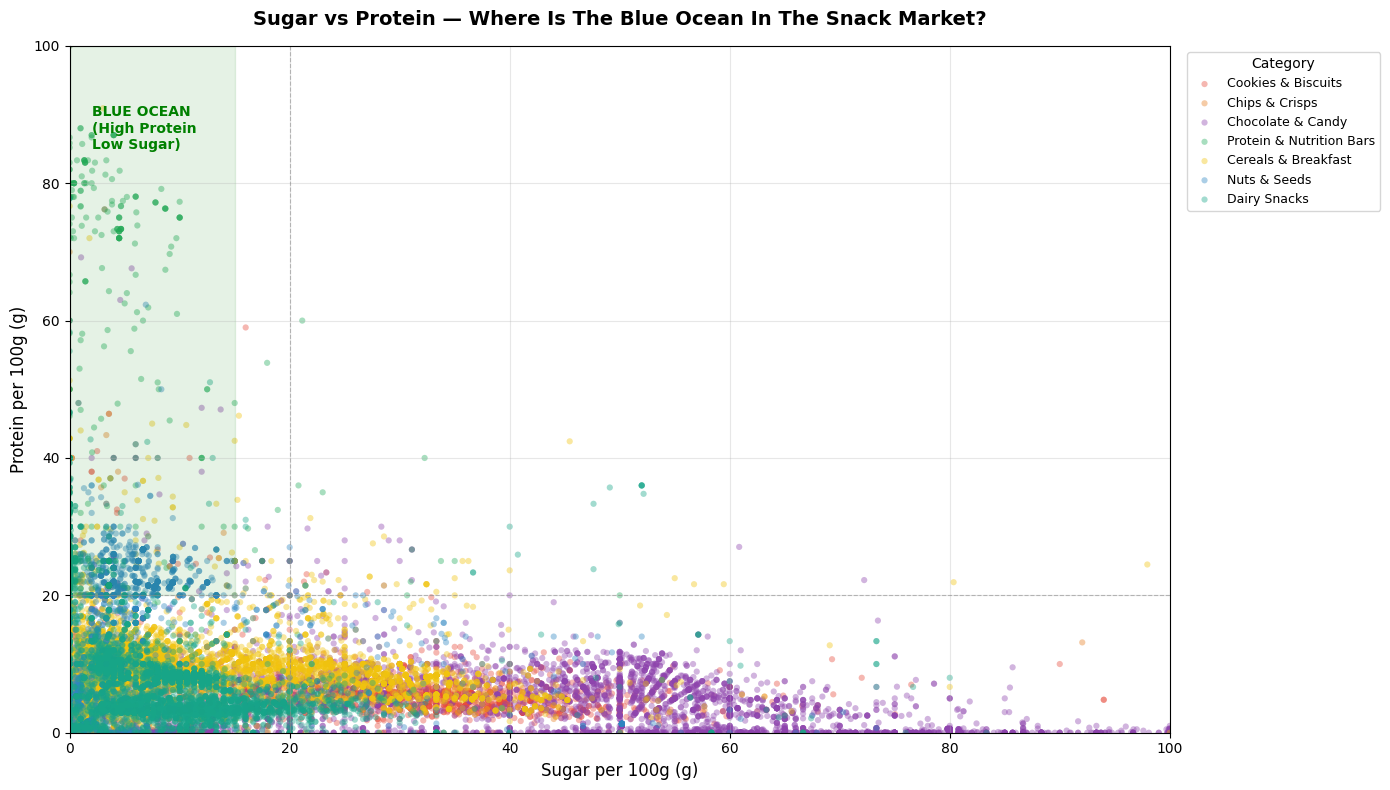

Scatter plot saved as scatter_plot.png!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# set the size of the chart — width 14 height 8 inches
fig, ax = plt.subplots(figsize=(14, 8))

# loop through each category and plot its products as dots
for category, color in category_colors.items():
    # filter to only products in this category
    subset = df_viz[df_viz['primary_category'] == category]
    ax.scatter(
        subset['sugars_100g'],    # x axis — sugar content
        subset['proteins_100g'],  # y axis — protein content
        c=color,                  # color of the dots
        label=category,           # label for the legend
        alpha=0.4,                # transparency of dots — 0 invisible 1 solid
        s=20,                     # size of each dot
        edgecolors='none'         # no border around dots
    )

# add a shaded rectangle to highlight the Blue Ocean quadrant
# this is the key visual — high protein low sugar area
ax.axhspan(20, 100, xmin=0, xmax=0.15, alpha=0.1, color='green')
ax.text(2, 85, 'BLUE OCEAN\n(High Protein\nLow Sugar)',
        fontsize=10, color='green', fontweight='bold')

# add reference lines to divide the chart into quadrants
ax.axhline(y=20, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)  # horizontal line at protein 20g
ax.axvline(x=20, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)  # vertical line at sugar 20g

# add chart title and axis labels
ax.set_title('Sugar vs Protein — Where Is The Blue Ocean In The Snack Market?',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Sugar per 100g (g)', fontsize=12)
ax.set_ylabel('Protein per 100g (g)', fontsize=12)

# set the axis limits so the chart is not too stretched
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

# add the legend so we know which color is which category
ax.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

# add a light grid so it is easier to read values
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scatter_plot.png', dpi=150, bbox_inches='tight')  # save chart as image
plt.show()

print("Scatter plot saved as scatter_plot.png!")

### **AVERAGE NUTRITION BY CATEGORY**

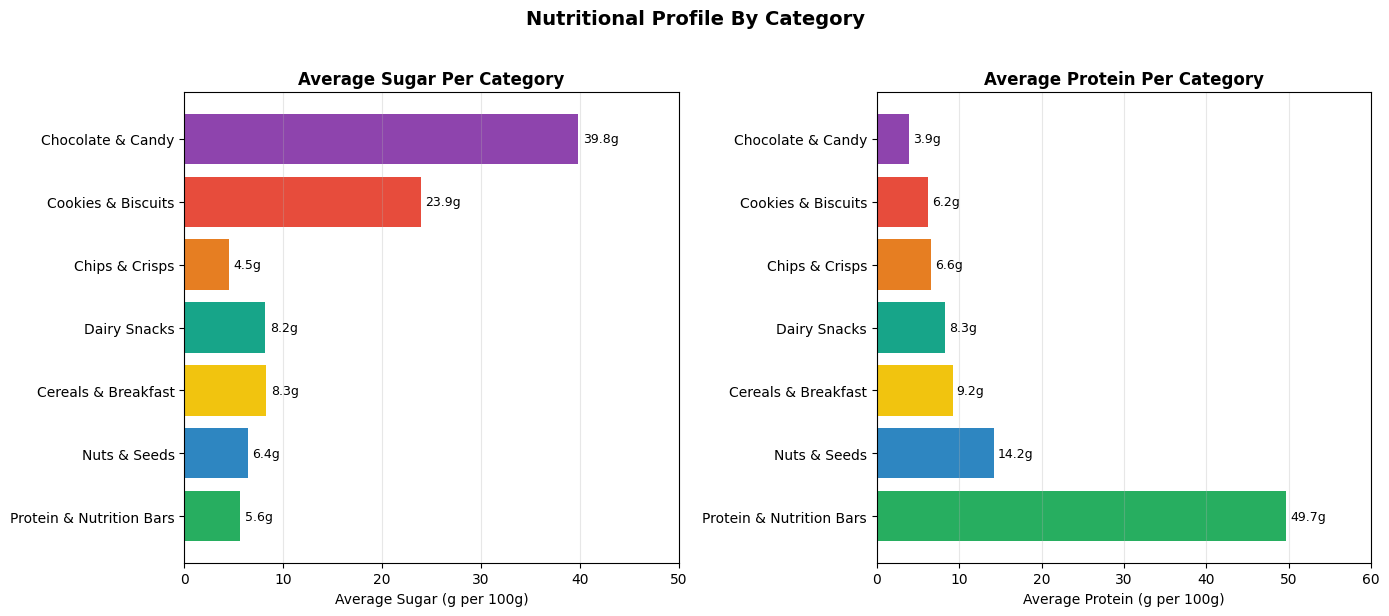

Chart saved as nutrition_by_category.png!

Average nutrition per category:

        primary_category  avg_sugar  avg_protein
Protein & Nutrition Bars        5.6         49.7
            Nuts & Seeds        6.4         14.2
     Cereals & Breakfast        8.3          9.2
            Dairy Snacks        8.2          8.3
          Chips & Crisps        4.5          6.6
      Cookies & Biscuits       23.9          6.2
       Chocolate & Candy       39.8          3.9


In [ ]:
# calculate the average sugar and protein for each category

# this gives us one number per category instead of thousands of dots
category_avg = df_viz.groupby('primary_category').agg(
    avg_sugar   = ('sugars_100g',   'mean'),  # average sugar per category
    avg_protein = ('proteins_100g', 'mean')   # average protein per category
).round(1).reset_index()

# sort by average protein from highest to lowest
category_avg = category_avg.sort_values('avg_protein', ascending=False)

# create a figure with two charts side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 - Average Sugar Per Category
colors_sugar = [category_colors[cat] for cat in category_avg['primary_category']]
bars1 = ax1.barh(
    category_avg['primary_category'],  # categories on y axis
    category_avg['avg_sugar'],         # average sugar on x axis
    color=colors_sugar,                # color each bar by category
    edgecolor='none'                   # no border around bars
)

# add the exact number at the end of each bar
for bar, value in zip(bars1, category_avg['avg_sugar']):
    ax1.text(
        bar.get_width() + 0.5,   # position slightly after the bar ends
        bar.get_y() + bar.get_height() / 2,  # center vertically on bar
        f'{value}g',             # the number to display
        va='center', fontsize=9  # vertically centered small font
    )

ax1.set_title('Average Sugar Per Category', fontsize=12, fontweight='bold')
ax1.set_xlabel('Average Sugar (g per 100g)', fontsize=10)
ax1.set_xlim(0, 50)  # set x axis limit
ax1.grid(True, alpha=0.3, axis='x')  # light vertical grid lines

# Chart 2 - Average Protein Per Category
colors_protein = [category_colors[cat] for cat in category_avg['primary_category']]
bars2 = ax2.barh(
    category_avg['primary_category'],  # categories on y axis
    category_avg['avg_protein'],       # average protein on x axis
    color=colors_protein,              # color each bar by category
    edgecolor='none'                   # no border around bars
)

# add the exact number at the end of each bar
for bar, value in zip(bars2, category_avg['avg_protein']):
    ax2.text(
        bar.get_width() + 0.5,   # position slightly after the bar ends
        bar.get_y() + bar.get_height() / 2,  # center vertically on bar
        f'{value}g',             # the number to display
        va='center', fontsize=9  # vertically centered small font
    )

ax2.set_title('Average Protein Per Category', fontsize=12, fontweight='bold')
ax2.set_xlabel('Average Protein (g per 100g)', fontsize=10)
ax2.set_xlim(0, 60)  # set x axis limit
ax2.grid(True, alpha=0.3, axis='x')  # light vertical grid lines

plt.suptitle('Nutritional Profile By Category', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nutrition_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as nutrition_by_category.png!")
print("\nAverage nutrition per category:\n")
print(category_avg.to_string(index=False))

### **PRODUCT COUNT BY CATEGORY**

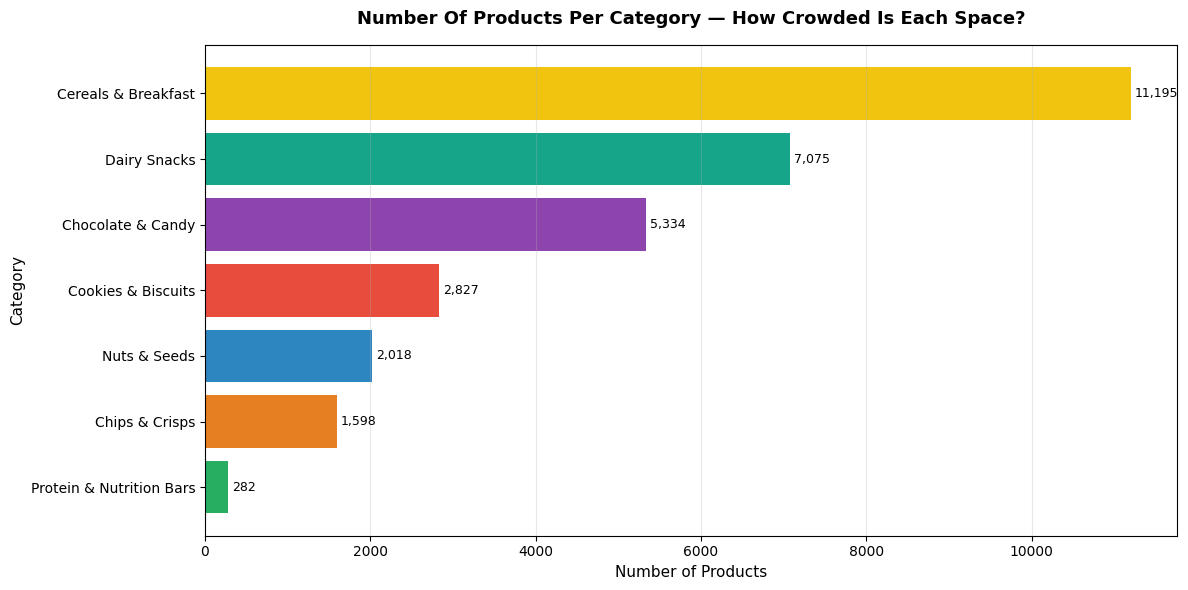

Chart saved as product_count_by_category.png!

Product count per category:

  Protein & Nutrition Bars          282 products
  Chips & Crisps                  1,598 products
  Nuts & Seeds                    2,018 products
  Cookies & Biscuits              2,827 products
  Chocolate & Candy               5,334 products
  Dairy Snacks                    7,075 products
  Cereals & Breakfast            11,195 products


In [ ]:
# count how many products exist in each category
# this shows how crowded or empty each category is
category_counts = df_viz['primary_category'].value_counts().reset_index()
category_counts.columns = ['primary_category', 'count']

# sort by count from highest to lowest
category_counts = category_counts.sort_values('count', ascending=True)

# create the chart
fig, ax = plt.subplots(figsize=(12, 6))

# assign colors to each bar based on category
colors = [category_colors[cat] for cat in category_counts['primary_category']]

# draw horizontal bar chart
bars = ax.barh(
    category_counts['primary_category'],  # categories on y axis
    category_counts['count'],             # product count on x axis
    color=colors,                         # color each bar by category
    edgecolor='none'                      # no border around bars
)

# add the exact count at the end of each bar
for bar, value in zip(bars, category_counts['count']):
    ax.text(
        bar.get_width() + 50,            # position slightly after bar ends
        bar.get_y() + bar.get_height() / 2,  # center vertically on bar
        f'{value:,}',                    # format number with comma separator
        va='center', fontsize=9          # vertically centered small font
    )

# add chart title and axis labels
ax.set_title('Number Of Products Per Category — How Crowded Is Each Space?',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Number of Products', fontsize=11)
ax.set_ylabel('Category', fontsize=11)

# add a light grid so it is easier to read values
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('product_count_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as product_count_by_category.png!")
print("\nProduct count per category:\n")
for _, row in category_counts.iterrows():
    print(f"  {row['primary_category']:<30} {row['count']:>6,} products")

# **THE RECOMMENDATION - STORY 4 (CELL 21)**

In [ ]:
# filter to only Protein & Nutrition Bars
# this is the category we identified as the Blue Ocean
protein_bars = df_viz[df_viz['primary_category'] == 'Protein & Nutrition Bars']

# calculate the average protein and sugar for this category
avg_protein = round(protein_bars['proteins_100g'].mean(), 1)
avg_sugar   = round(protein_bars['sugars_100g'].mean(), 1)

# median is the middle value — less affected by extreme outliers
median_protein = round(protein_bars['proteins_100g'].median(), 1)
median_sugar   = round(protein_bars['sugars_100g'].median(), 1)

# we use median as our target because it is realistic for
# a mainstream healthy snacking product not a supplement
target_protein = median_protein
target_sugar   = median_sugar

# print the heading
print("KEY INSIGHT & PRODUCT RECOMMENDATION\n")

# print the full recommendation in one block
print(f"""
Based on the analysis of {len(df_viz):,} snack products across 7 categories
the data reveals a clear market gap. The snack market is heavily saturated
in high sugar low protein categories like Chocolate & Candy (39.8g sugar, 3.9g protein)
and Cookies & Biscuits (23.9g sugar, 6.2g protein).

However the Protein & Nutrition Bars category is severely underserved
with only {len(protein_bars)} products in the entire dataset.

Based on the data the biggest market opportunity is in Protein & Nutrition Bars
specifically targeting products with {target_protein}g of protein and less than {target_sugar}g of sugar.

Supporting Data:
  - Average protein : {avg_protein}g    Average sugar : {avg_sugar}g
  - Median protein  : {median_protein}g    Median sugar  : {median_sugar}g
  - Total products in category : {len(protein_bars)}
  - Total products analyzed    : {len(df_viz):,}
""")

KEY INSIGHT & PRODUCT RECOMMENDATION


Based on the analysis of 30,329 snack products across 7 categories
the data reveals a clear market gap. The snack market is heavily saturated
in high sugar low protein categories like Chocolate & Candy (39.8g sugar, 3.9g protein)
and Cookies & Biscuits (23.9g sugar, 6.2g protein).

However the Protein & Nutrition Bars category is severely underserved
with only 282 products in the entire dataset.

Based on the data the biggest market opportunity is in Protein & Nutrition Bars
specifically targeting products with 58.1g of protein and less than 3.4g of sugar.

Supporting Data:
  - Average protein : 49.7g    Average sugar : 5.6g
  - Median protein  : 58.1g    Median sugar  : 3.4g
  - Total products in category : 282
  - Total products analyzed    : 30,329



# **BONUS STORY - THE HIDDEN GEM (CELLS 22-23)**

### **FILTER HIGH PROTEIN PRODUCTS**

In [ ]:
# we define high protein as products with more than 20g of protein
# this is a common threshold used in sports nutrition
HIGH_PROTEIN_THRESHOLD = 20

# filter products that are high protein AND low sugar
# these are the products in our Blue Ocean quadrant
high_protein_products = df_viz[
    (df_viz['proteins_100g'] > HIGH_PROTEIN_THRESHOLD) &  # more than 20g protein
    (df_viz['sugars_100g']   < 20)                        # less than 20g sugar
].copy()

print(f"High protein threshold : above {HIGH_PROTEIN_THRESHOLD}g protein per 100g")
print(f"Low sugar threshold    : below 20g sugar per 100g")
print(f"Products in Blue Ocean : {len(high_protein_products):,}")
print(f"\nCategory breakdown of Blue Ocean products:\n")

# count how many Blue Ocean products exist in each category
blue_ocean_counts = high_protein_products['primary_category'].value_counts()
for category, count in blue_ocean_counts.items():
    pct = (count / len(high_protein_products)) * 100
    print(f"  {category:<30} {count:>5,}  ({pct:.1f}%)")

High protein threshold : above 20g protein per 100g
Low sugar threshold    : below 20g sugar per 100g
Products in Blue Ocean : 2,033

Category breakdown of Blue Ocean products:

  Dairy Snacks                     894  (44.0%)
  Nuts & Seeds                     709  (34.9%)
  Protein & Nutrition Bars         206  (10.1%)
  Cereals & Breakfast              124  (6.1%)
  Chocolate & Candy                 63  (3.1%)
  Cookies & Biscuits                22  (1.1%)
  Chips & Crisps                    15  (0.7%)


### **EXTRACT TOP PROTEIN INGREDIENTS**

In [ ]:
from collections import Counter
import re

# filter only high protein products that have ingredients listed
# we need the ingredients_text column to find protein sources
high_protein_with_ingredients = high_protein_products[
    high_protein_products['ingredients_text'].notna()  # only rows with ingredients
].copy()

print(f"High protein products with ingredients listed: {len(high_protein_with_ingredients):,}\n")

# these are the protein source keywords we are looking for
# we search for these words inside the ingredients text
protein_keywords = [
    'whey', 'peanut', 'almond', 'soy', 'casein',
    'egg', 'milk', 'pea protein', 'chickpea', 'lentil',
    'quinoa', 'hemp', 'walnut', 'cashew', 'pistachio'
]

# count how many times each protein keyword appears
# across all high protein product ingredients
keyword_counts = Counter()

for ingredients in high_protein_with_ingredients['ingredients_text']:
    # convert to lowercase so Whey and whey both match
    ingredients_lower = str(ingredients).lower()
    for keyword in protein_keywords:
        if keyword in ingredients_lower:   # check if keyword exists in ingredients
            keyword_counts[keyword] += 1   # add 1 to its count

# print the top 10 most common protein sources
print("Top protein sources found in high protein products:\n")
for rank, (ingredient, count) in enumerate(keyword_counts.most_common(10), 1):
    pct = (count / len(high_protein_with_ingredients)) * 100
    bar = '#' * int(pct / 2)
    print(f"  {rank}. {ingredient:<20} found in {count:>4} products  ({pct:.1f}%)  {bar}")

High protein products with ingredients listed: 1,226

Top protein sources found in high protein products:

  1. milk                 found in  486 products  (39.6%)  ###################
  2. peanut               found in  285 products  (23.2%)  ###########
  3. soy                  found in  178 products  (14.5%)  #######
  4. almond               found in   98 products  (8.0%)  ###
  5. whey                 found in   79 products  (6.4%)  ###
  6. pistachio            found in   33 products  (2.7%)  #
  7. pea protein          found in   27 products  (2.2%)  #
  8. lentil               found in   26 products  (2.1%)  #
  9. casein               found in   24 products  (2.0%)  
  10. cashew               found in   24 products  (2.0%)  


# **CANDIDATE'S CHOICE - HEALTH SCORE ANALYSIS**

### **CALCULATE HEALTH SCORE**

In [ ]:

# this combines all nutrients into one easy to understand number
# the formula rewards good nutrients and penalizes bad ones
# Health Score = (protein x 2) + (fiber x 1.5) - (sugar x 1) - (fat x 0.5)

df_viz['health_score'] = (
    (df_viz['proteins_100g'] * 2.0) +         # reward protein heavily
    (df_viz['fiber_100g'].fillna(0) * 1.5) +  # reward fiber (fill NaN with 0)
    (df_viz['sugars_100g'] * -1.0) +           # penalize sugar
    (df_viz['fat_100g'] * -0.5)                # penalize fat lightly
).round(1)

print("Health scores calculated!\n")
print(f"Highest possible score : very positive number = very healthy")
print(f"Lowest possible score  : very negative number = very unhealthy")
print(f"\nOverall health score summary:\n")
print(f"  Average health score : {df_viz['health_score'].mean().round(1)}")
print(f"  Highest score        : {df_viz['health_score'].max()}")
print(f"  Lowest score         : {df_viz['health_score'].min()}")
print(f"\nAverage health score by category:\n")

# calculate average health score per category
# sort from highest to lowest so best categories appear first
health_by_category = (
    df_viz.groupby('primary_category')['health_score']
    .mean()
    .round(1)
    .sort_values(ascending=False)
)

for category, score in health_by_category.items():
    print(f"  {category:<30} {score:>6}")

Health scores calculated!

Highest possible score : very positive number = very healthy
Lowest possible score  : very negative number = very unhealthy

Overall health score summary:

  Average health score : 0.4
  Highest score        : 273.6
  Lowest score         : -100.0

Average health score by category:

  Protein & Nutrition Bars         96.1
  Cereals & Breakfast              13.8
  Nuts & Seeds                     11.4
  Dairy Snacks                      4.8
  Chips & Crisps                    2.8
  Cookies & Biscuits              -16.3
  Chocolate & Candy               -34.7


**VISUALIZE HEALTH SCORE BY CATEGORY**

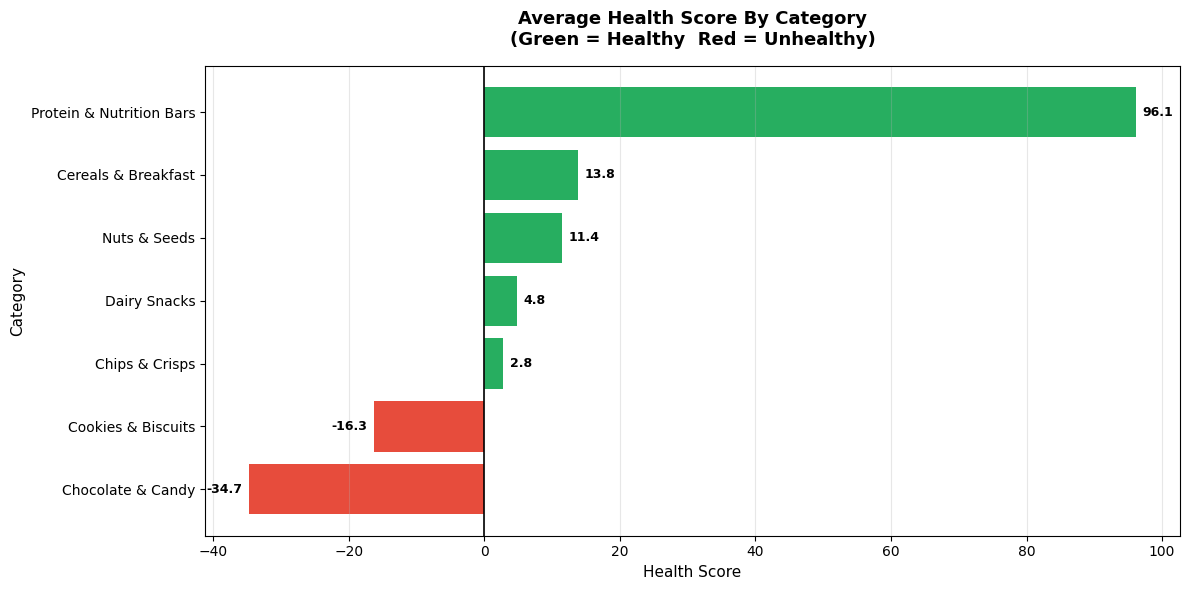

Chart saved as health_score_by_category.png!


In [ ]:
# sort categories by health score from lowest to highest
# ascending=True puts the least healthy at the bottom
health_by_category_sorted = health_by_category.sort_values(ascending=True)

# create the chart
fig, ax = plt.subplots(figsize=(12, 6))

# assign colors based on score
# positive scores get green negative scores get red
bar_colors = [
    '#27AE60' if score > 0 else '#E74C3C'
    for score in health_by_category_sorted.values
]

# draw horizontal bar chart
bars = ax.barh(
    health_by_category_sorted.index,   # categories on y axis
    health_by_category_sorted.values,  # health scores on x axis
    color=bar_colors,                  # green or red based on score
    edgecolor='none'                   # no border around bars
)

# add the exact score at the end of each bar
for bar, value in zip(bars, health_by_category_sorted.values):
    x_position = value + 1 if value >= 0 else value - 1  # position label correctly
    alignment  = 'left' if value >= 0 else 'right'        # align label correctly
    ax.text(
        x_position,
        bar.get_y() + bar.get_height() / 2,  # center vertically on bar
        f'{value}',                           # score to display
        va='center',
        ha=alignment,
        fontsize=9,
        fontweight='bold'
    )

# add a vertical line at zero to separate healthy from unhealthy
ax.axvline(x=0, color='black', linewidth=1.2)

# add chart title and axis labels
ax.set_title('Average Health Score By Category\n(Green = Healthy  Red = Unhealthy)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Health Score', fontsize=11)
ax.set_ylabel('Category', fontsize=11)

# add a light grid
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('health_score_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as health_score_by_category.png!")

### **SAVE FINAL CSV FOR STREAMLIT**

In [ ]:
# at this point df_viz has all the columns we need for the dashboard
# save this as the final dataset that Streamlit will use

# check what columns we have in df_viz
print("Columns in final dataset:\n")
for col in df_viz.columns:
    print(f"  {col}")

# save the final dataset
df_viz.to_csv('food_facts_final.csv', index=False)

print(f"\nFinal dataset saved as food_facts_final.csv")
print(f"Total rows saved : {len(df_viz):,}")
print(f"Total columns    : {df_viz.shape[1]}")

Columns in final dataset:

  product_name
  categories_tags
  sugars_100g
  proteins_100g
  fat_100g
  fiber_100g
  energy_100g
  ingredients_text
  categories_clean
  primary_category
  health_score

Final dataset saved as food_facts_final.csv
Total rows saved : 30,329
Total columns    : 11
